<style>
code, pre {
    white-space: pre-wrap !important;
    word-wrap: break-word !important;
}
</style>

# Algorithms and Code 
## Static Modeling of the Problem
### General Framework
This is the pseudo-code used in the **Static Modeling**. This is a **constrained** version of Multi-Armed Bandit (MAB) problem. 

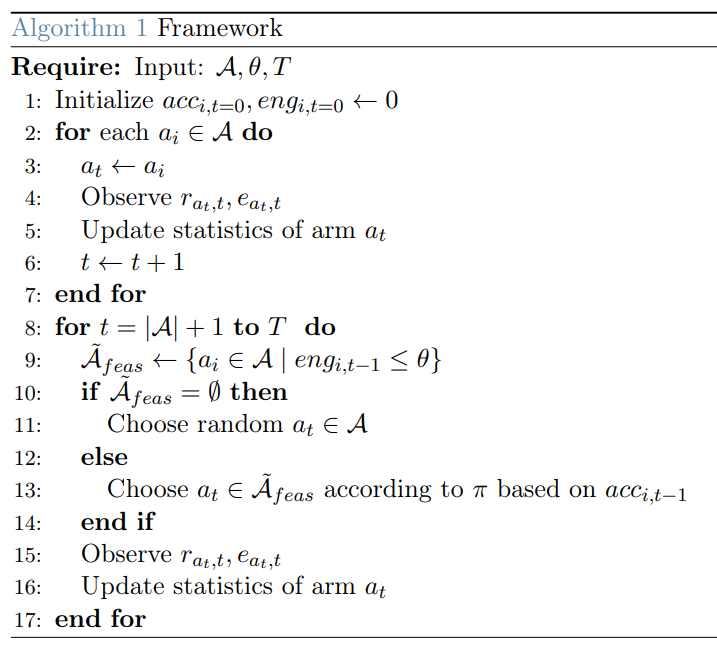


In this work, different constrained MAB algorithms were considered: $\epsilon$-greedy, Upper Confidence Bound (UCB) and Thompson Sampling.

#### Epsilon-greedy
* with a probability 1-$\epsilon$: agent chooses the best arm in term of estimated mean reward;
* with a probability $\epsilon$: agent chooses a random arm.


In [ ]:
import numpy as np
import random
##===========ONLY SELECT ACTION PART=======================
def selectActions(self):
    arm_feasible_tilde=[i for i in self.valid_arms if self.armMeanEngagements[i] <= self.th_eng] #Check constraint 

    if self.currentStep<len(self.valid_arms):
        selectedArmIndex=self.valid_arms[self.currentStep] #Test all arms once
    else:
        probabilityDraw=np.random.rand() 
        if (probabilityDraw<=self.epsilon):
            selectedArmIndex=np.random.choice(self.valid_arms) #Selects a random arm with an epsilon probability

        if (probabilityDraw>self.epsilon):
            if arm_feasible_tilde:
                selectedArmIndex=max(arm_feasible_tilde, key=lambda i: self.armMeanRewards[i]) #Selects arm with maximum estimated mean reward 
            if not arm_feasible_tilde:
                selectedArmIndex=np.random.choice(self.valid_arms) #Fallback

    #========================
    # Variable Update
    self.currentStep=self.currentStep+1

    self.counts[selectedArmIndex]=self.counts[selectedArmIndex]+1
        
    #=========================
    # Recieves current REWARD + current ENGAGEMENT (constraint) --> randomly draw from the data 
    acc_list=self.hist_acc[selectedArmIndex] 
    eng_list=self.hist_eng[selectedArmIndex]

    random_index=random.randrange(len(acc_list)) 
    
    self.currentReward=acc_list[random_index] 
    self.currentEngagement=eng_list[random_index]
    
    #============================
    #Update GENERAL Mean Reward 
    self.meanReward[self.currentStep]=self.meanReward[self.currentStep-1]+(1/(self.currentStep))*(self.currentReward-self.meanReward[self.currentStep-1]) 

    self.CumulativeReward[self.currentStep]=self.CumulativeReward[self.currentStep-1]+self.currentReward
        
    # Update ARM Mean Reward
    self.armMeanRewards[selectedArmIndex]=self.armMeanRewards[selectedArmIndex]+(1/(self.counts[selectedArmIndex]))*(self.currentReward-self.armMeanRewards[selectedArmIndex])

    # Update Mean Engagement                   
    self.armMeanEngagements[selectedArmIndex]=self.armMeanEngagements[selectedArmIndex]+(1/(self.counts[selectedArmIndex]))*(self.currentEngagement -self.armMeanEngagements[selectedArmIndex]) 

#### UCB
It uses upper confidence bound for estimated mean reward (optimism) and the lower confidence bound for constraint (optimism)

In [ ]:
def selectActions(self):
    arm_feasible_tilde=[i for i in self.valid_arms if self.LCB[i] <= self.th_eng] #Check constraint (with LCB)  
    
    if self.currentStep<len(self.valid_arms):
        selectedArmIndex=self.valid_arms[self.currentStep] #Test all arms once
    else:               
        if arm_feasible_tilde:
            selectedArmIndex=max(arm_feasible_tilde, key=lambda i: self.UCB[i]) #Selection based on UCB related to estimated mean reward
        if not arm_feasible_tilde:
            selectedArmIndex=np.random.choice(self.valid_arms) #Fallback

    #====================================
    # Variable update

    self.currentStep=self.currentStep+1

    self.counts[selectedArmIndex]=self.counts[selectedArmIndex]+1
        
    #======================
    # Update Current REWARD + ENGAGEMENT
    acc_list=self.hist_acc[selectedArmIndex]
    eng_list=self.hist_eng[selectedArmIndex]

    random_index=random.randrange(len(acc_list))
    
    self.currentReward=acc_list[random_index]
    self.currentEngagement=eng_list[random_index]
    
    #===============================
    # Update General Mean Reward 
    self.meanReward[self.currentStep]=self.meanReward[self.currentStep-1]+(1/(self.currentStep))*(self.currentReward-self.meanReward[self.currentStep-1])

    self.CumulativeReward[self.currentStep]=self.CumulativeReward[self.currentStep-1]+self.currentReward

    # Update Confidence Bound
    for a in self.valid_arms:
        if self.counts[a]>0:
            self.armConfidenceBound[a]=np.sqrt((2*np.log(self.currentStep))/self.counts[a]) #for both LCB and UCB
        
    # Update Arm Mean Reward and Arm Mean Engagement 
    self.armMeanRewards[selectedArmIndex]=self.armMeanRewards[selectedArmIndex]+(1/(self.counts[selectedArmIndex]))*(self.currentReward-self.armMeanRewards[selectedArmIndex]) 

    self.armMeanEngagements[selectedArmIndex]=self.armMeanEngagements[selectedArmIndex]+(1/(self.counts[selectedArmIndex]))*(self.currentEngagement-self.armMeanEngagements[selectedArmIndex])

    # Update UCB and LCB
    self.UCB=self.armMeanRewards+self.armConfidenceBound
    self.LCB=self.armMeanEngagements-self.armConfidenceBound

#### Thompson Sampling
Each action is associated with beta distribution, that acts ad probability model of expected mean reward (and of the constraint).

In [ ]:
def selectActions(self):
    # Starting from the uniform distribution, it extracts a sample for each arm
    samples_acc=np.random.beta(self.beta_parameters_acc[:,0], self.beta_parameters_acc[:,1]) 
    samples_eng=np.random.beta(self.beta_parameters_eng[:,0], self.beta_parameters_eng[:,1])

    arm_feasible_tilde=[i for i in self.valid_arms if samples_eng[i]<=self.th_eng] #Cehck constraint     
    
    if self.currentStep<len(self.valid_arms):
        selectedArmIndex=self.valid_arms[self.currentStep] #Test all arms once
    else:
        if arm_feasible_tilde:       
            selectedArmIndex=max(arm_feasible_tilde, key=lambda i: samples_acc[i]) #Selects best arm in term of reward
        if not arm_feasible_tilde:
            selectedArmIndex=np.random.choice(self.valid_arms) #Fallback  
    
    #====================================
    # Update Variable
    self.currentStep=self.currentStep+1

    self.counts[selectedArmIndex]=self.counts[selectedArmIndex]+1
        
    #==================================
    # Update Current REWARD + ENGAGEMENT  
    acc_list=self.hist_acc[selectedArmIndex]
    eng_list=self.hist_eng[selectedArmIndex]

    random_index=random.randrange(len(acc_list))
    
    self.currentReward=acc_list[random_index]
    self.currentEngagement=eng_list[random_index]

    #====================================
    # Update General Mean Reward
        
    self.meanReward[self.currentStep]=self.meanReward[self.currentStep-1]+(1/(self.currentStep))*(self.currentReward-self.meanReward[self.currentStep-1])

    self.CumulativeReward[self.currentStep]=self.CumulativeReward[self.currentStep-1]+self.currentReward
        
    #Uodate ARM Mean Reward
    self.armMeanRewards[selectedArmIndex]=self.armMeanRewards[selectedArmIndex]+(1/(self.counts[selectedArmIndex]))*(self.currentReward-self.armMeanRewards[selectedArmIndex]) 

    #Update ARM Mean Engagement
    self.armMeanEngagements[selectedArmIndex]=self.armMeanEngagements[selectedArmIndex]+(1/(self.counts[selectedArmIndex]))*(self.currentEngagement-self.armMeanEngagements[selectedArmIndex])

    #Update alpha and beta parameters of beta distributions
    success_acc=1 if np.random.rand()<self.currentReward else 0 #if 1 update alpha, if 0 update beta
    self.beta_parameters_acc[selectedArmIndex,0]=self.beta_parameters_acc[selectedArmIndex,0]+success_acc 
    self.beta_parameters_acc[selectedArmIndex,1]=self.beta_parameters_acc[selectedArmIndex,1]+1-success_acc

    success_eng=1 if np.random.rand()<self.currentEngagement else 0
    self.beta_parameters_eng[selectedArmIndex,0]=self.beta_parameters_eng[selectedArmIndex,0]+success_eng
    self.beta_parameters_eng[selectedArmIndex,1]=self.beta_parameters_eng[selectedArmIndex,1]+1-success_eng